In [1]:
import numpy as np
import pickle
import time
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load saved data
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test  = np.load('../data/processed/y_test.npy')
le      = pickle.load(open('../models/label_encoder.pkl', 'rb'))

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("Classes:", le.classes_)

# Isolation Forest trains on BENIGN only
# It learns what "normal" looks like — anything else = anomaly
X_benign = X_train[y_train == 0]  # 0 = Benign
print(f"\nTraining on {X_benign.shape[0]} benign samples only")

X_train: (40000, 46)
X_test:  (10000, 46)
Classes: ['Benign' 'DDoS' 'DoS' 'Mirai' 'Recon']

Training on 8000 benign samples only


In [2]:
print("Training Isolation Forest...")

t0 = time.perf_counter()

iso = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)
iso.fit(X_benign)

train_time = time.perf_counter() - t0
print(f"✓ Training time: {train_time:.2f}s")

Training Isolation Forest...
✓ Training time: 0.38s


In [3]:
# Predict on test set
t0 = time.perf_counter()
preds = iso.predict(X_test)   # -1 = anomaly, 1 = normal
infer_time = (time.perf_counter() - t0) * 1000

# Convert to binary: attack=1, benign=0
y_binary    = (y_test != 0).astype(int)   # 0=Benign, rest=attack
pred_binary = (preds == -1).astype(int)   # -1=anomaly = attack

print("=" * 55)
print("TABLE 2 — Isolation Forest Results")
print("=" * 55)
print(classification_report(y_binary, pred_binary,
      target_names=['Benign', 'Attack']))

print(f"Inference time (10k samples) : {infer_time:.1f} ms")
print(f"Per-sample latency           : {infer_time/len(X_test):.4f} ms")
print(f"Training time                : {train_time:.2f} s")

TABLE 2 — Isolation Forest Results
              precision    recall  f1-score   support

      Benign       0.29      0.95      0.45      2000
      Attack       0.97      0.42      0.59      8000

    accuracy                           0.53     10000
   macro avg       0.63      0.69      0.52     10000
weighted avg       0.84      0.53      0.56     10000

Inference time (10k samples) : 108.8 ms
Per-sample latency           : 0.0109 ms
Training time                : 0.38 s


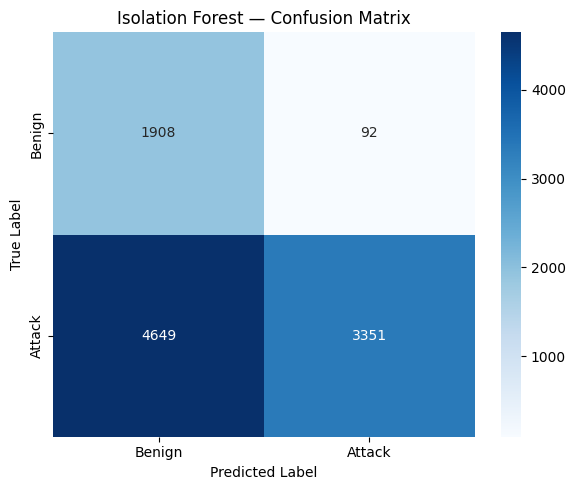

✓ Saved to results/confusion_matrix.png


In [4]:
cm = confusion_matrix(y_binary, pred_binary)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'])
plt.title('Isolation Forest — Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../results/confusion_matrix.png', dpi=150)
plt.show()
print("✓ Saved to results/confusion_matrix.png")

In [5]:
pickle.dump(iso, open('../models/isolation_forest.pkl', 'wb'))
print("✓ Isolation Forest saved to models/isolation_forest.pkl")

print("\n--- Models ready for agents ---")
print("  ✓ models/scaler.pkl")
print("  ✓ models/label_encoder.pkl")
print("  ✓ models/cuckoo_filter.pkl")
print("  ✓ models/isolation_forest.pkl")

✓ Isolation Forest saved to models/isolation_forest.pkl

--- Models ready for agents ---
  ✓ models/scaler.pkl
  ✓ models/label_encoder.pkl
  ✓ models/cuckoo_filter.pkl
  ✓ models/isolation_forest.pkl


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

print("Training Random Forest (supervised)...")

t0 = time.perf_counter()
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_train_time = time.perf_counter() - t0

# Predict
t0 = time.perf_counter()
rf_preds = rf.predict(X_test)
rf_infer_time = (time.perf_counter() - t0) * 1000

print(f"✓ Training time: {rf_train_time:.2f}s")
print(f"✓ Inference time: {rf_infer_time:.1f}ms")
print()
print("=" * 55)
print("TABLE 2B — Random Forest Results")
print("=" * 55)
print(classification_report(y_test, rf_preds,
      target_names=le.classes_))

Training Random Forest (supervised)...
✓ Training time: 2.75s
✓ Inference time: 173.0ms

TABLE 2B — Random Forest Results
              precision    recall  f1-score   support

      Benign       0.91      0.95      0.93      2000
        DDoS       1.00      1.00      1.00      2000
         DoS       1.00      1.00      1.00      2000
       Mirai       1.00      1.00      1.00      2000
       Recon       0.95      0.91      0.93      2000

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [8]:
import hashlib
import numpy as np

class CuckooFilter:
    def __init__(self, capacity=20000, bucket_size=4, max_kicks=500):
        self.capacity    = capacity
        self.bucket_size = bucket_size
        self.max_kicks   = max_kicks
        self.buckets     = [[None]*bucket_size for _ in range(capacity)]
        self.size        = 0

    def _fingerprint(self, item):
        return hashlib.md5(str(item).encode()).hexdigest()[:8]

    def _hash1(self, item):
        return int(hashlib.sha256(str(item).encode()).hexdigest(), 16) % self.capacity

    def _hash2(self, fp, h1):
        return (h1 ^ int(hashlib.sha256(fp.encode()).hexdigest(), 16)) % self.capacity

    def insert(self, item):
        fp = self._fingerprint(item)
        i1 = self._hash1(item)
        i2 = self._hash2(fp, i1)
        for i in [i1, i2]:
            if None in self.buckets[i]:
                self.buckets[i][self.buckets[i].index(None)] = fp
                self.size += 1
                return True
        i = i1
        for _ in range(self.max_kicks):
            slot = np.random.randint(self.bucket_size)
            fp, self.buckets[i][slot] = self.buckets[i][slot], fp
            i = self._hash2(fp, i)
            if None in self.buckets[i]:
                self.buckets[i][self.buckets[i].index(None)] = fp
                self.size += 1
                return True
        return False

    def lookup(self, item):
        fp = self._fingerprint(item)
        i1 = self._hash1(item)
        i2 = self._hash2(fp, i1)
        return fp in self.buckets[i1] or fp in self.buckets[i2]

    def delete(self, item):
        fp = self._fingerprint(item)
        i1 = self._hash1(item)
        i2 = self._hash2(fp, i1)
        for i in [i1, i2]:
            if fp in self.buckets[i]:
                self.buckets[i][self.buckets[i].index(fp)] = None
                self.size -= 1
                return True
        return False

print("✓ CuckooFilter class ready — now run Cell 7")

✓ CuckooFilter class ready — now run Cell 7


In [11]:
# This is your full pipeline for the paper
# Stage 1: Cuckoo Filter catches known threats instantly
# Stage 2: Isolation Forest flags anomalies
# Stage 3: Random Forest classifies the attack type
import pandas as pd

FEATURE_COLS = [
    'flow_duration','Header_Length','Protocol Type','Duration','Rate',
    'Srate','Drate','fin_flag_number','syn_flag_number','rst_flag_number',
    'psh_flag_number','ack_flag_number','ece_flag_number','cwr_flag_number',
    'ack_count','syn_count','fin_count','urg_count','rst_count','HTTP',
    'HTTPS','DNS','Telnet','SMTP','SSH','IRC','TCP','UDP','DHCP','ARP',
    'ICMP','IPv','LLC','Tot sum','Min','Max','AVG','Std','Tot size','IAT',
    'Number','Magnitue','Radius','Covariance','Variance','Weight'
]
cf_loaded  = pickle.load(open('../models/cuckoo_filter.pkl', 'rb'))
df         = pd.read_csv('../data/my_iot_dataset.csv')

def make_signature(row):
    return f"{round(row['Rate'], 1)}_{row['Protocol Type']}_{row['ICMP']}"

# Run hybrid pipeline on test portion of dataset
test_df = df.sample(1000, random_state=99).reset_index(drop=True)

results = {
    'true_label': [],
    'stage_caught': [],
    'predicted': [],
    'latency_ms': []
}

scaler_loaded = pickle.load(open('../models/scaler.pkl', 'rb'))

for _, row in test_df.iterrows():
    t0  = time.perf_counter()
    sig = make_signature(row)

    # Stage 1: Cuckoo filter
    if cf_loaded.lookup(sig):
        stage     = 'cuckoo_filter'
        predicted = 'Attack'

    else:
        features = np.array(row[FEATURE_COLS].values,
                            dtype=np.float32).reshape(1, -1)
        features_scaled = scaler_loaded.transform(features)

        # Stage 2: Isolation Forest
        iso_pred = iso.predict(features_scaled)[0]

        if iso_pred == -1:
            stage     = 'isolation_forest'
            predicted = 'Attack'
        else:
            # Stage 3: Random Forest classifies
            rf_pred   = rf.predict(features_scaled)[0]
            stage     = 'random_forest'
            predicted = le.classes_[rf_pred]

    latency = (time.perf_counter() - t0) * 1000
    results['true_label'].append(row['category'])
    results['stage_caught'].append(stage)
    results['predicted'].append(predicted)
    results['latency_ms'].append(round(latency, 4))

results_df = pd.DataFrame(results)

print("=" * 55)
print("TABLE 3 — Hybrid Pipeline Stage Distribution")
print("=" * 55)
print(results_df['stage_caught'].value_counts())
print(f"\nAvg latency per packet: {results_df['latency_ms'].mean():.4f} ms")
print(f"Max latency per packet: {results_df['latency_ms'].max():.4f} ms")

TABLE 3 — Hybrid Pipeline Stage Distribution
stage_caught
cuckoo_filter       907
random_forest        87
isolation_forest      6
Name: count, dtype: int64

Avg latency per packet: 6.4163 ms
Max latency per packet: 143.7880 ms


In [12]:
import pickle
pickle.dump(rf, open('../models/random_forest.pkl', 'wb'))
print("✓ Random Forest saved")

✓ Random Forest saved
